# FNet-Style Phasor Transformer - Non-Linear Threshold Stacking

This notebook establishes a **Variational Phasor Transformer** to analyze an oscillatory time-series sequence.

Instead of traditional attention ($Q K^T V$), this model implements the mathematically equivalent **FNet** Transformer Block. 
To address the user's hypothesis about structural cascading, we are explicitly enforcing purely topological geometric normalization. We insert a **Non-Linear Threshold Gate** (`tau=0.5`) strictly between Transformer Layer 1 and Layer 2 to analyze if snapping the state back to the $N$-Torus manifold restricts or stabilizes high-frequency sequence processing.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import phasorflow as pf
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

np.random.seed(42)
torch.manual_seed(42)

## 1. Synthetic Oscillatory Sequence Generation
We synthesize a complex waveform (combining multiple sine frequencies and adding some noise).
We will frame the data such that $T=10$ sequence steps are used to predict the value of the next step $T+1$.


In [2]:
time_steps = 200
T = 10 # Sequence Context Window Length

# Generate base oscillation waveform (composite of 3 frequencies)
t_axis = np.linspace(0, 10 * np.pi, time_steps)
signal = np.sin(t_axis) + 0.5 * np.cos(3 * t_axis) + 0.25 * np.sin(7 * t_axis)
# Add slight noise
signal += np.random.normal(0, 0.1, time_steps)

# Frame into (X, y) sequences
X_seq = []
y_seq = []

for i in range(len(signal) - T):
    X_seq.append(signal[i:i+T])
    y_seq.append(signal[i+T])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# Linear Encoding to [-pi/2, pi/2] to preserve Autoregressive Sine dynamics!
max_val = np.max(np.abs(signal))
X_seq_norm = (X_seq / max_val) * (np.pi / 2)
y_seq_norm = (y_seq / max_val) * (np.pi / 2)

# Split into Train / Test (80/20) and cast to PyTorch Tensors
split = int(len(X_seq) * 0.8)
X_train = torch.tensor(X_seq_norm[:split], dtype=torch.float32)
y_train = torch.tensor(y_seq_norm[:split], dtype=torch.float32)
X_test = torch.tensor(X_seq_norm[split:], dtype=torch.float32)
y_test = torch.tensor(y_seq_norm[split:], dtype=torch.float32)

print(f"Generated {X_train.shape[0]} Training Sequences and {X_test.shape[0]} Test Sequences of length T={T}")

Generated 152 Training Sequences and 38 Test Sequences of length T=10


## 2. Transformer FNet Architecture (Non-Linear Interruption)
We split the monolithic Transformer into discrete mathematical runs so we can apply `apply_threshold_gate()` strictly on intermediate amplitude lengths.

In [3]:
def create_transformer_layer(x_phases, w_pre, w_post, layer_id=0):
    pc = pf.PhasorCircuit(T, name=f"Transformer_Block_{layer_id}")
    
    # Data Encoding / Passthrough from previous state
    for i in range(T):
        pc.shift(i, x_phases[i])
        
    # FNet Transformer Topology
    for i in range(T):
        pc.shift(i, w_pre[i])
    pc.dft()
    for i in range(T):
        pc.shift(i, w_post[i])
        
    return pc

def apply_threshold_gate(phases, amplitudes, tau=0.5):
    # Use PyTorch out-of-place masking to preserve the Autograd graph tracking
    mask = (amplitudes >= tau).float()
    new_phases = phases * mask
    return new_phases

backend = pf.Simulator.get_backend('analytic_simulator')

def vpc_predict_step(x_seq, weights):
    # Architecture requires exactly 50 parameters
    w_L1_pre = weights[0:10]
    w_L1_post = weights[10:20]
    w_L2_pre = weights[20:30]
    w_L2_post = weights[30:40]
    w_readout = weights[40:50]
    
    # --- Layer 1 Execution ---
    pc1 = create_transformer_layer(x_seq, w_L1_pre, w_L1_post, layer_id=1)
    res1 = backend.run(pc1)
    
    # --- Non-Linear Amplitude S1-Restabilization! ---
    intermediate_phases = apply_threshold_gate(res1['phases'], torch.abs(res1['state_vector']), tau=0.5)
    
    # --- Layer 2 Execution ---
    pc2 = create_transformer_layer(intermediate_phases, w_L2_pre, w_L2_post, layer_id=2)
    res2 = backend.run(pc2)
    
    # --- Sequence Readout ---
    final_phases = res2['phases']
    # Add final projection mathematically
    projected_phases = final_phases + w_readout
    
    # Extract predictive phase directly from index 0
    return projected_phases[0]

# Initial weights tracked by PyTorch Autograd
initial_weights = torch.empty(50).uniform_(-np.pi/10, np.pi/10).requires_grad_()
print("Untrained Non-Linear Prediction:", vpc_predict_step(X_train[0], initial_weights).item())

Untrained Non-Linear Prediction: 0.3449729382991791


## 3. Training Loop (Mean Squared Error)
We optimize our sequence-predicting network parameters utilizing the powerful continuous optimization algorithm **L-BFGS-B**, minimizing Mean Squared Error (MSE), explicitly carrying topological boundaries forward.


In [4]:
def mse_loss(weights):
    predictions = torch.stack([vpc_predict_step(x, weights) for x in X_train])
    loss = torch.mean((predictions - y_train)**2)
    return loss

initial_loss = mse_loss(initial_weights)
print(f"Initial Starting Loss: {initial_loss.item():.4f}")

print("Starting Adam Sequence Optimization Over Threshold Pipeline...")
optimizer = optim.Adam([initial_weights], lr=0.05)
EPOCHS = 100

for epoch in range(EPOCHS):
    optimizer.zero_grad()
    loss = mse_loss(initial_weights)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")

optimal_weights = initial_weights.detach()
print(f"\nFinal Optimized Loss (Threshold Constraints): {loss.item():.4f}")

Initial Starting Loss: 0.9615
Starting Adam Sequence Optimization Over Threshold Pipeline...


Epoch   0 | Loss: 0.9615


Epoch  10 | Loss: 0.4928


Epoch  20 | Loss: 0.2529


Epoch  30 | Loss: 0.2335


...

Epoch  60 | Loss: 0.2247


Epoch  70 | Loss: 0.1839


Epoch  80 | Loss: 0.1912


Epoch  90 | Loss: 0.1653



Final Optimized Loss (Threshold Constraints): 0.1705


## 4. Evaluation and Prediction Visualization
Now we analyze if non-linear restabilization of the structural vector helps or hurts sequence extrapolation context.


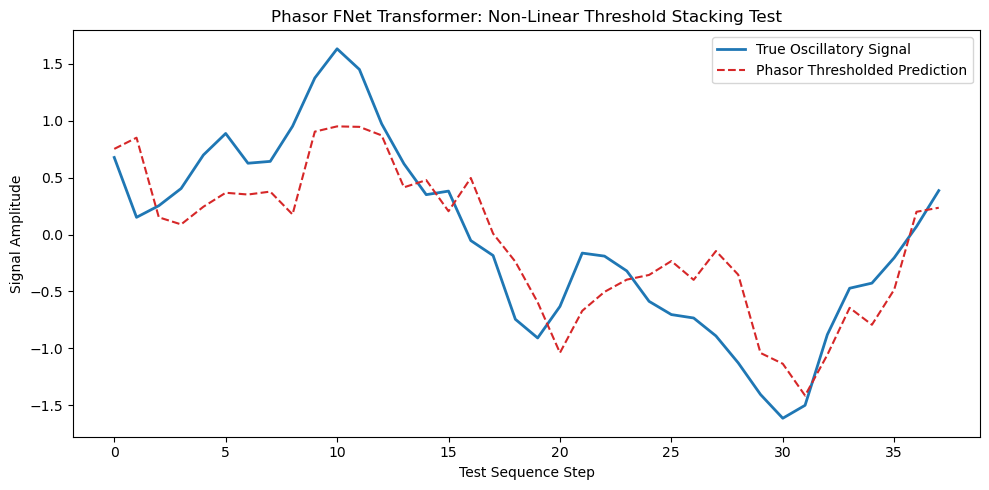

Test Set Prediction MSE (With Threshold Gates): 0.1660


In [5]:
# Generate Predictions on Test Set
with torch.no_grad():
    test_predictions_norm = torch.stack([vpc_predict_step(x, optimal_weights) for x in X_test])

# De-normalize outputs back to raw signal domain
test_predictions_true = (test_predictions_norm * max_val / (np.pi / 2)).numpy()
y_test_true = (y_test * max_val / (np.pi / 2)).numpy()

# Plot Results
plt.figure(figsize=(10, 5))
plt.plot(y_test_true, label="True Oscillatory Signal", color='tab:blue', linewidth=2)
plt.plot(test_predictions_true, label="Phasor Thresholded Prediction", color='tab:red', linestyle='--')
plt.title("Phasor FNet Transformer: Non-Linear Threshold Stacking Test")
plt.xlabel("Test Sequence Step")
plt.ylabel("Signal Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

final_mse = np.mean((test_predictions_true - y_test_true)**2)
print(f"Test Set Prediction MSE (With Threshold Gates): {final_mse:.4f}")